<a href="https://colab.research.google.com/github/berkantaydin2512/Visualization/blob/main/LogisticRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [65]:
import numpy as np
import pandas as pd
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns
import cufflinks as cf
import plotly.express as px
%matplotlib inline

# Library for feature Scaling
from sklearn.preprocessing import RobustScaler

#Libraries for logistic Regression Model Building
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split


#Library for evaluation
from sklearn import metrics
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [67]:
train_data = pd.read_csv('/content/kaggle/input/titanic/train.csv')
test_data = pd.read_csv('/content/kaggle/input/titanic/test.csv')


In [68]:
train_data.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [69]:
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [70]:
test_data.columns

Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [71]:
test_data.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [72]:
train_data.shape

(891, 12)

In [73]:
train_data.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [74]:
train_data_num_col = train_data.select_dtypes(exclude=['object']).columns
train_data_num = train_data[train_data_num_col]

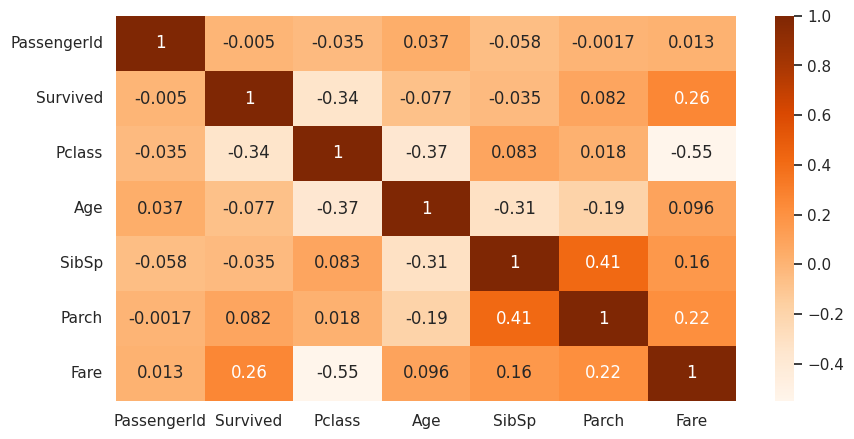

In [75]:
plt.figure(figsize=(10, 5))
sns.heatmap(train_data_num.corr(), annot=True, cmap='Oranges');

In [76]:
correlation = abs(pd.DataFrame(train_data_num.corr().Survived))
correlation

,Survived
PassengerId,0.005007
Survived,1.000000
Pclass,0.338481
Age,0.077221
SibSp,0.035322
Parch,0.081629
Fare,0.257307


<Axes: >

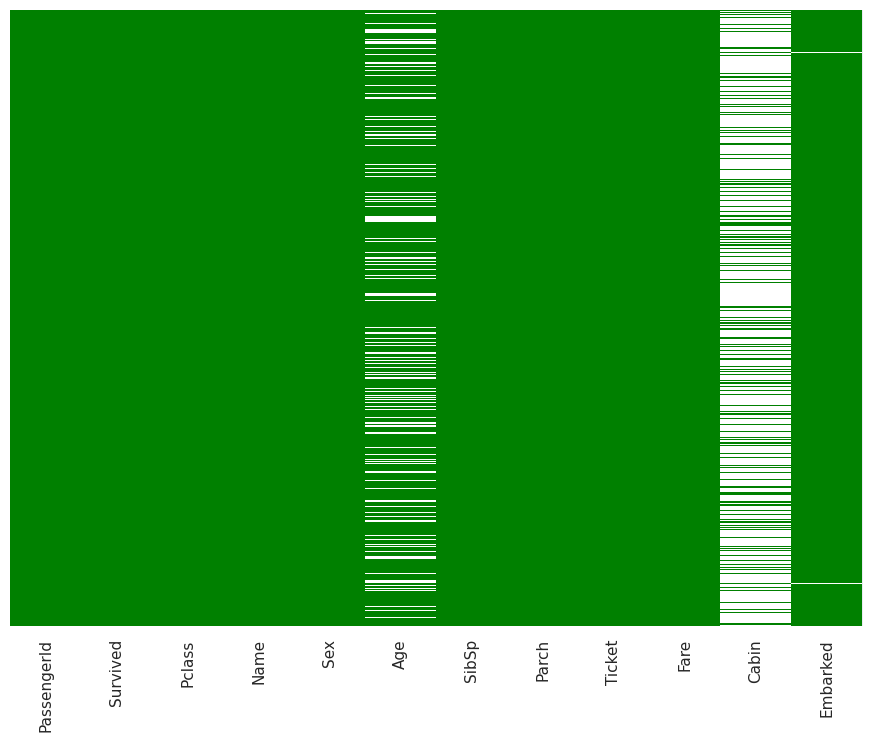

In [77]:
sns.set(rc={'figure.figsize':(11,8)})
sns.heatmap(train_data.isnull(),yticklabels=False,cbar=False,cmap="ocean")

In [78]:
train_data['Survived'].value_counts()

,count
Survived,
0,549
1,342


In [79]:
train_data['Pclass'].value_counts()

,count
Pclass,
3,491
1,216
2,184


In [80]:
train_data['Embarked'].value_counts()

,count
Embarked,
S,644
C,168
Q,77


/tmp/ipython-input-3097837114.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




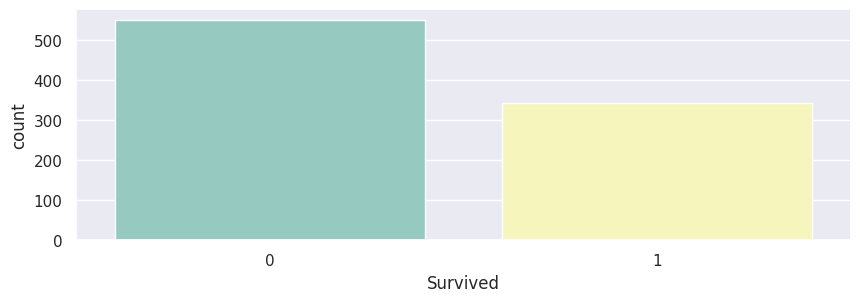

In [81]:
plt.figure(figsize=(10, 3))
sns.countplot(x = "Survived",data=train_data, palette="Set3")
plt.show()

/tmp/ipython-input-672434163.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




<Figure size 1000x300 with 0 Axes>

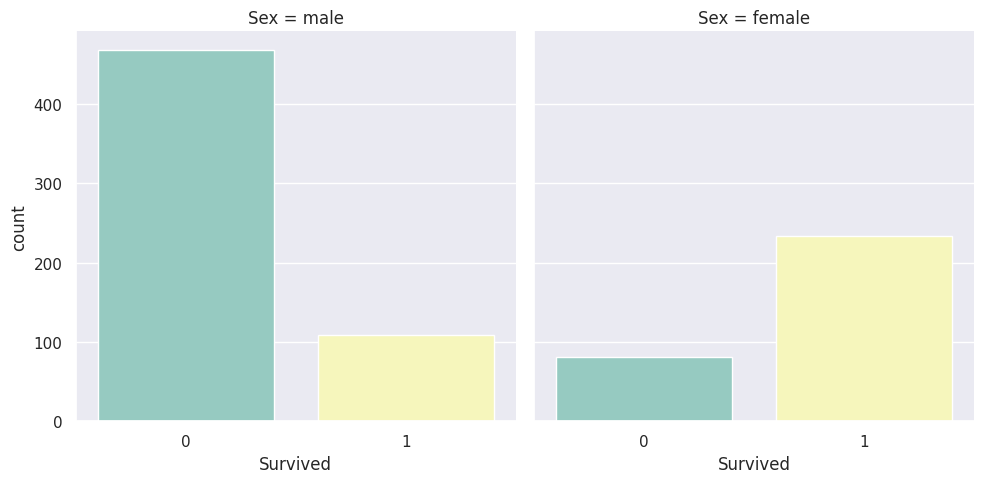

In [82]:
plt.figure(figsize=(10, 3))
sns.catplot(x='Survived', col='Sex', kind='count', data=train_data,palette="Set3");
plt.show()

/tmp/ipython-input-1219211128.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




<Figure size 1000x300 with 0 Axes>

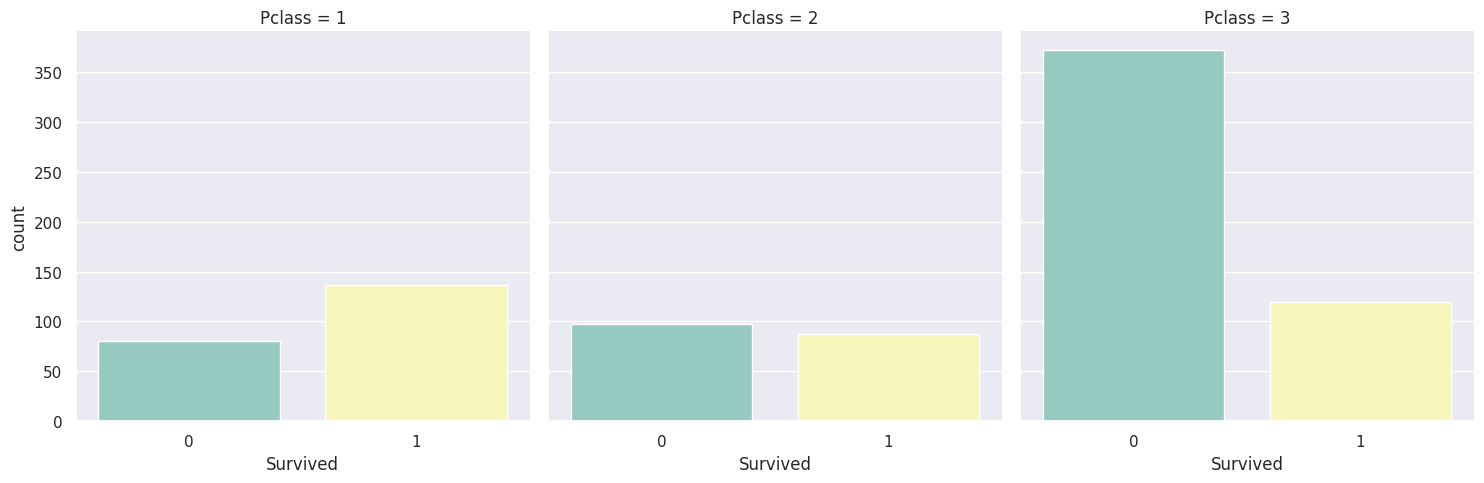

In [83]:
plt.figure(figsize=(10, 3))
sns.catplot(x='Survived', col='Pclass', kind='count', data=train_data,palette="Set3");
plt.show()

<Figure size 1000x300 with 0 Axes>

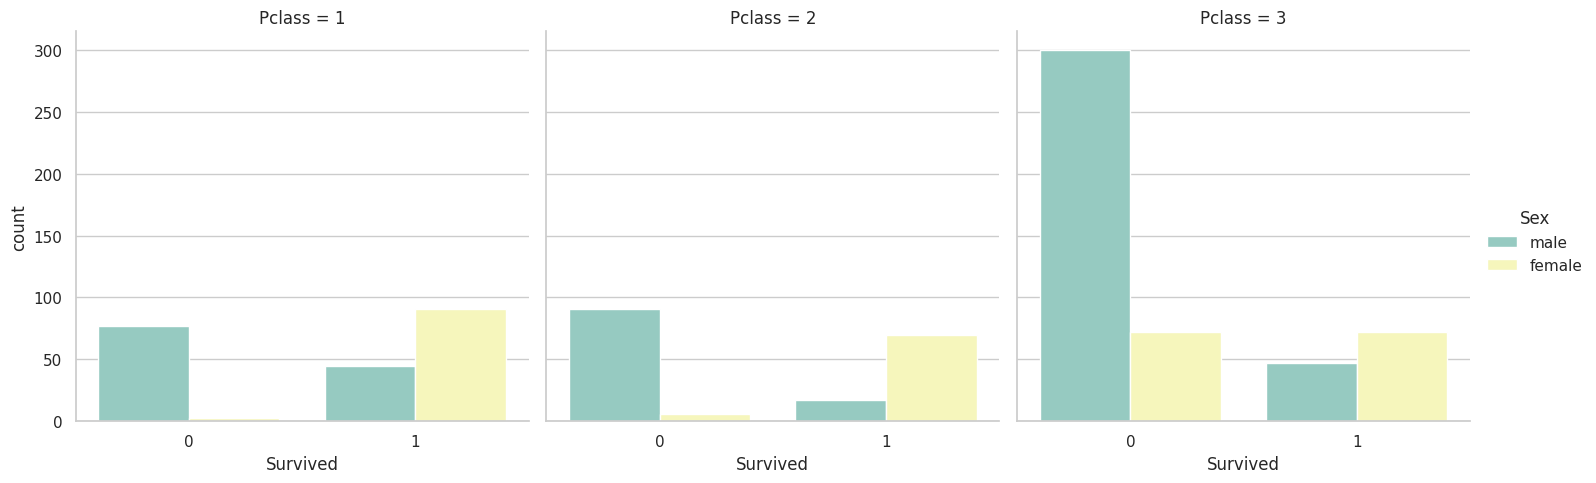

In [84]:
plt.figure(figsize=(10, 3))
sns.set_style('whitegrid')
sns.catplot(x='Survived', col='Pclass', hue = 'Sex', kind='count', data=train_data,palette="Set3");
plt.show()

/tmp/ipython-input-1466868222.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




<Figure size 1000x300 with 0 Axes>

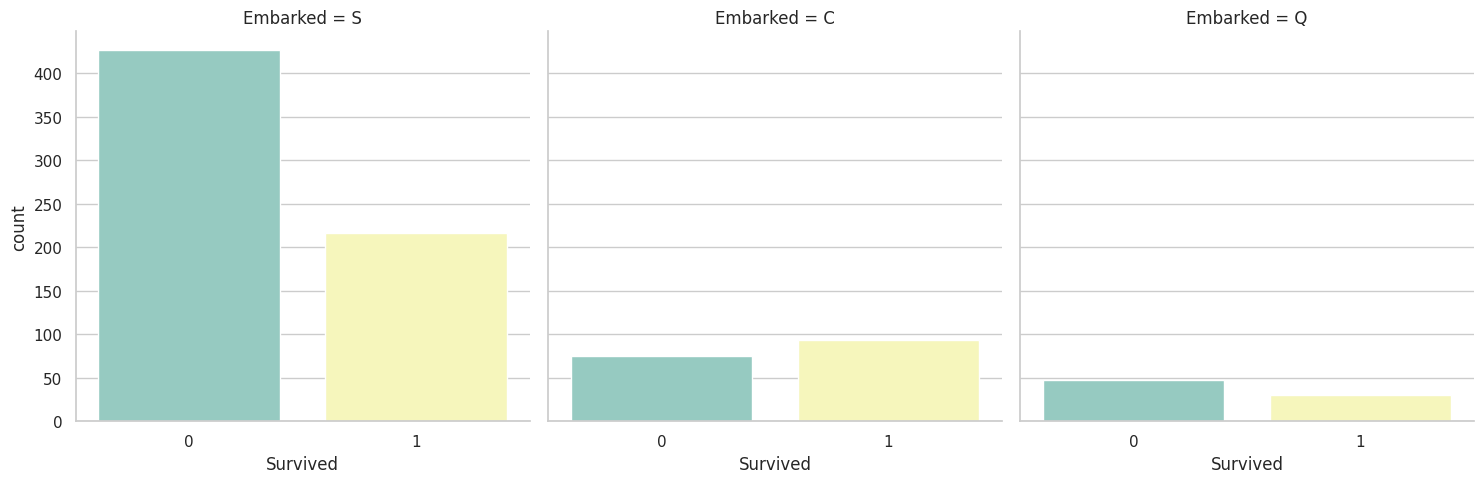

In [85]:
plt.figure(figsize=(10, 3))
sns.set_style('whitegrid')
sns.catplot(x='Survived', col='Embarked', kind='count', data=train_data,palette="Set3");
plt.show()

<Figure size 1000x300 with 0 Axes>

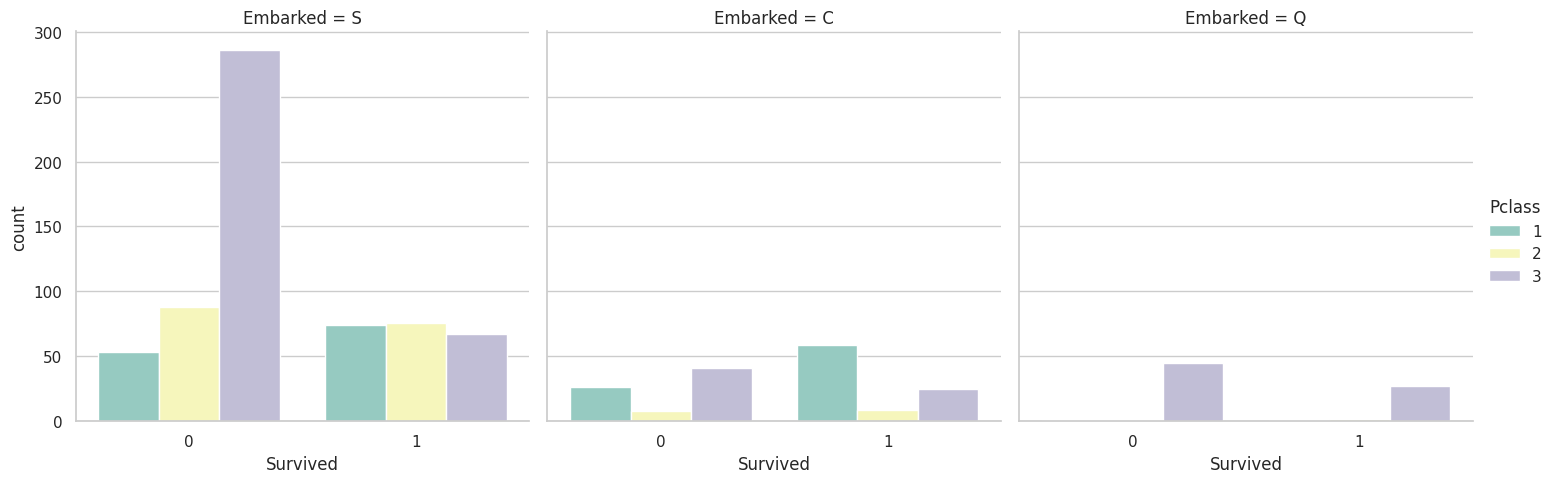

In [86]:
plt.figure(figsize=(10, 3))
sns.set_style('whitegrid')
sns.catplot(x='Survived', col='Embarked', hue = 'Pclass', kind='count', data=train_data,palette="Set3");
plt.show()

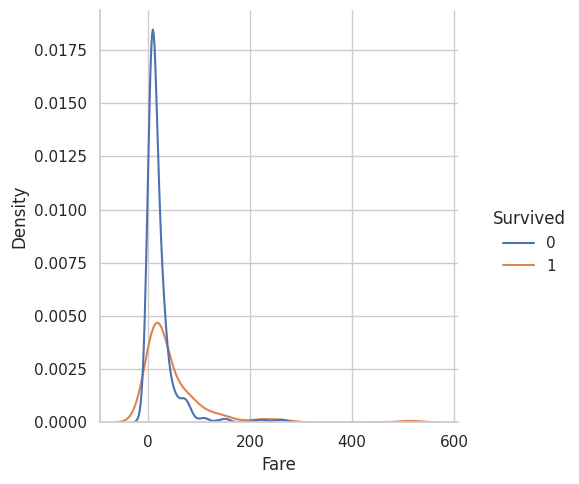

In [87]:
sns.displot(data=train_data, x="Fare",hue='Survived',kind ='kde')

In [88]:
pd.crosstab(train_data.Sex,train_data.Survived,normalize = "index" ).style.background_gradient(cmap='crest')

Survived,0,1
Sex,,
female,0.257962,0.742038
male,0.811092,0.188908


In [89]:
pd.crosstab(train_data.Pclass,train_data.Survived,normalize = "index" ).style.background_gradient(cmap='Spectral_r')

Survived,0,1
Pclass,,
1,0.370370,0.629630
2,0.527174,0.472826
3,0.757637,0.242363


In [90]:
pd.crosstab(train_data.Embarked,train_data.Survived,normalize = "index" ).style.background_gradient(cmap='Pastel1')

Survived,0,1
Embarked,,
C,0.446429,0.553571
Q,0.610390,0.389610
S,0.663043,0.336957


<Axes: xlabel='Age', ylabel='Count'>

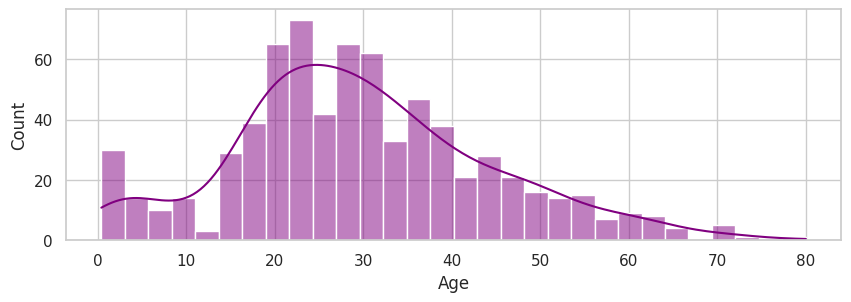

In [91]:
plt.figure(figsize=(10, 3))
sns.histplot(train_data['Age'].dropna(),kde=True,color='purple',bins=30)

In [92]:
cf.go_offline()
train_data['Age'].iplot(kind='hist',bins=35)

ValueError: 
    Invalid value of type 'builtins.str' received for the 'color' property of histogram.marker
        Received value: 'rgba(255, 153, 51, np.float64(1.0))'

    The 'color' property is a color and may be specified as:
      - A hex string (e.g. '#ff0000')
      - An rgb/rgba string (e.g. 'rgb(255,0,0)')
      - An hsl/hsla string (e.g. 'hsl(0,100%,50%)')
      - An hsv/hsva string (e.g. 'hsv(0,100%,100%)')
      - A named CSS color:
            aliceblue, antiquewhite, aqua, aquamarine, azure,
            beige, bisque, black, blanchedalmond, blue,
            blueviolet, brown, burlywood, cadetblue,
            chartreuse, chocolate, coral, cornflowerblue,
            cornsilk, crimson, cyan, darkblue, darkcyan,
            darkgoldenrod, darkgray, darkgrey, darkgreen,
            darkkhaki, darkmagenta, darkolivegreen, darkorange,
            darkorchid, darkred, darksalmon, darkseagreen,
            darkslateblue, darkslategray, darkslategrey,
            darkturquoise

/tmp/ipython-input-36354399.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




<Axes: xlabel='SibSp', ylabel='count'>

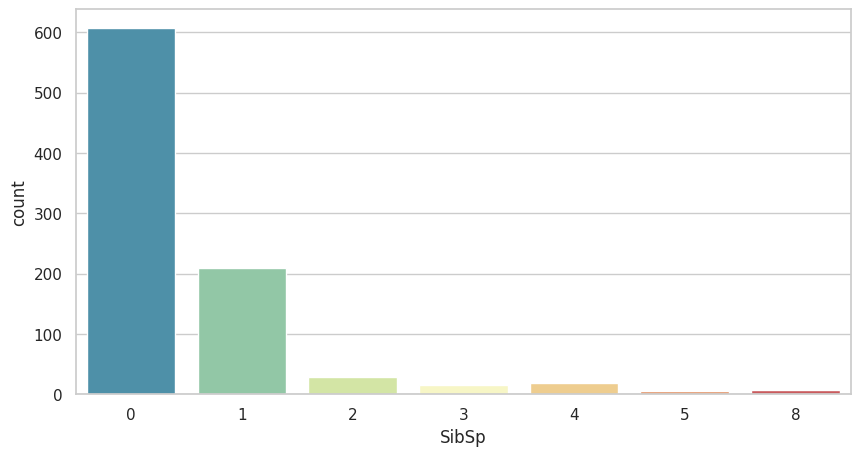

In [93]:
plt.figure(figsize=(10, 5))
sns.countplot(x='SibSp',data=train_data, palette='Spectral_r')

/tmp/ipython-input-3477012037.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




<Axes: xlabel='Parch', ylabel='count'>

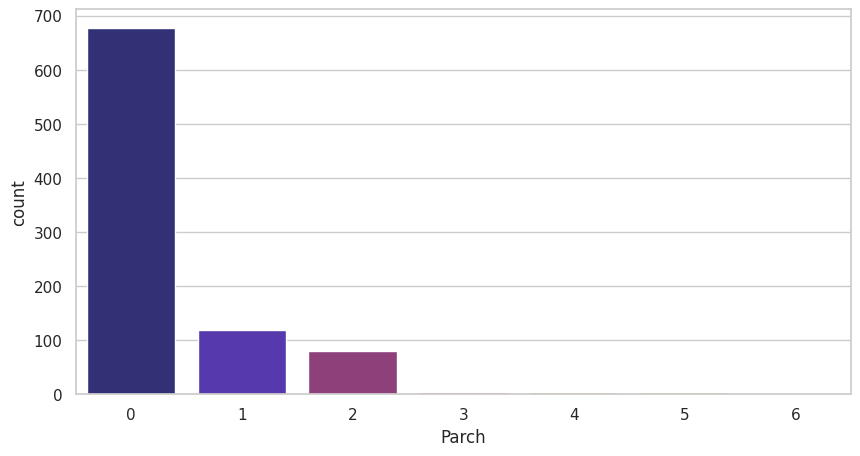

In [94]:
plt.figure(figsize=(10, 5))
sns.countplot(x='Parch',data=train_data,palette='CMRmap')

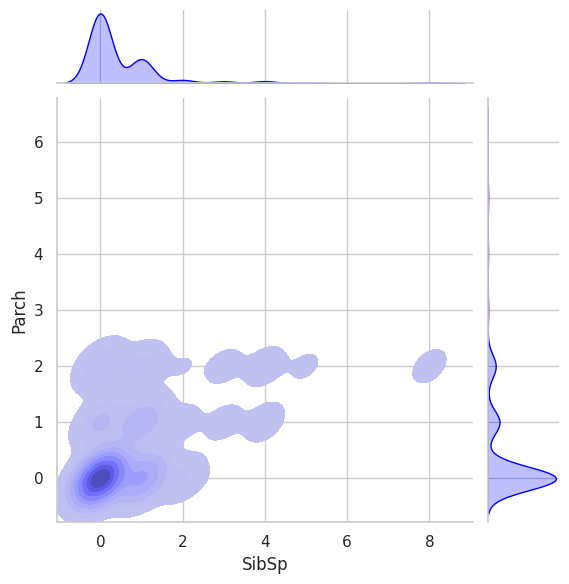

In [95]:
sns.jointplot(x='SibSp',y='Parch',data=train_data,color='blue',kind='kde', fill =True);

In [96]:
plt.figure(figsize=(10, 3))
fig = px.scatter_3d(train_data, x='Name', y='Sex', z='Age', color='Age')
fig.show()

<Figure size 1000x300 with 0 Axes>

In [97]:
train_data['Age'].isnull().sum()

np.int64(177)

Text(0.5, 1.0, 'Age over Pclass')

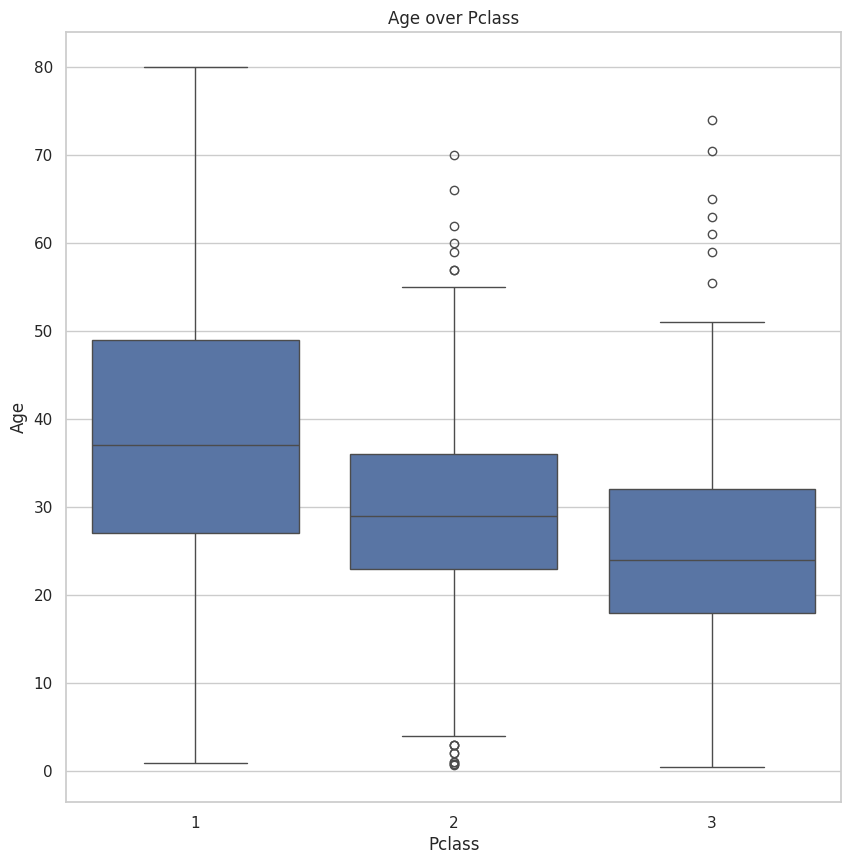

In [98]:
plt.figure(figsize=(10, 10))
sns.boxplot(x='Pclass',y='Age',data=train_data)
plt.title('Age over Pclass')

In [99]:
def impute_train_age(cols):
    Age = cols[0]
    Pclass = cols[1]

    if pd.isnull(Age):

        if Pclass == 1:
            return 37

        elif Pclass == 2:
            return 29

        else:
            return 24

    else:
        return Age

In [100]:
train_data['Age'] = train_data[['Age','Pclass']].apply(impute_train_age,axis=1)

/tmp/ipython-input-3981110378.py:2: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipython-input-3981110378.py:3: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



In [101]:
train_data['Age'].isnull().sum()

np.int64(0)

In [102]:
train_data['Cabin'].isnull().sum()

np.int64(687)

In [103]:
train_data.drop('Cabin',axis=1,inplace=True)

In [104]:
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [105]:
train_data.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [106]:
train_data.dropna(inplace=True)

In [107]:
train_data.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [108]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  889 non-null    int64  
 1   Survived     889 non-null    int64  
 2   Pclass       889 non-null    int64  
 3   Name         889 non-null    object 
 4   Sex          889 non-null    object 
 5   Age          889 non-null    float64
 6   SibSp        889 non-null    int64  
 7   Parch        889 non-null    int64  
 8   Ticket       889 non-null    object 
 9   Fare         889 non-null    float64
 10  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 83.3+ KB


In [109]:
train_data.drop(['Name','Ticket'],axis=1,inplace=True)

In [110]:
train_data.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,male,22.0,1,0,7.2500,S
1,2,1,1,female,38.0,1,0,71.2833,C
2,3,1,3,female,26.0,0,0,7.9250,S
3,4,1,1,female,35.0,1,0,53.1000,S
4,5,0,3,male,35.0,0,0,8.0500,S


In [111]:
train_data = pd.get_dummies(train_data, columns = ['Sex'], drop_first=True)
train_data = pd.get_dummies(train_data, columns = ['Embarked'], drop_first=True)

In [112]:
train_data.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,1,0,3,22.0,1,0,7.2500,True,False,True
1,2,1,1,38.0,1,0,71.2833,False,False,False
2,3,1,3,26.0,0,0,7.9250,False,False,True
3,4,1,1,35.0,1,0,53.1000,False,False,True
4,5,0,3,35.0,0,0,8.0500,True,False,True


In [113]:
train_data.drop('PassengerId',axis=1,inplace=True)

In [114]:
train_data.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


In [115]:
X = train_data.drop(['Survived'],axis = 1)
y = train_data['Survived']

In [116]:
X.head()

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,3,22.0,1,0,7.2500,True,False,True
1,1,38.0,1,0,71.2833,False,False,False
2,3,26.0,0,0,7.9250,False,False,True
3,1,35.0,1,0,53.1000,False,False,True
4,3,35.0,0,0,8.0500,True,False,True


In [117]:
y.head()

,Survived
0,0
1,1
2,1
3,1
4,0


In [118]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=101)

In [119]:
X_train.shape

(711, 8)

In [120]:
X_test.shape

(178, 8)

In [121]:
y_train.shape

(711,)

In [122]:
y_test.shape

(178,)

In [123]:
cols = X_train.columns

scaler = RobustScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train = pd.DataFrame(X_train,columns=cols)
X_test = pd.DataFrame(X_test,columns=cols)

In [124]:
LogisticRegression_model = LogisticRegression(max_iter=4000)
LogisticRegression_model.fit(X_train,y_train)

LogisticRegression(max_iter=4000)

In [125]:
y_pred = LogisticRegression_model.predict(X_test)

In [126]:
y_pred

array([0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0,
       0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0,
       1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0])

In [127]:
confusion_matrix = confusion_matrix(y_test,y_pred)
confusion_matrix

array([[98,  9],
       [24, 47]])

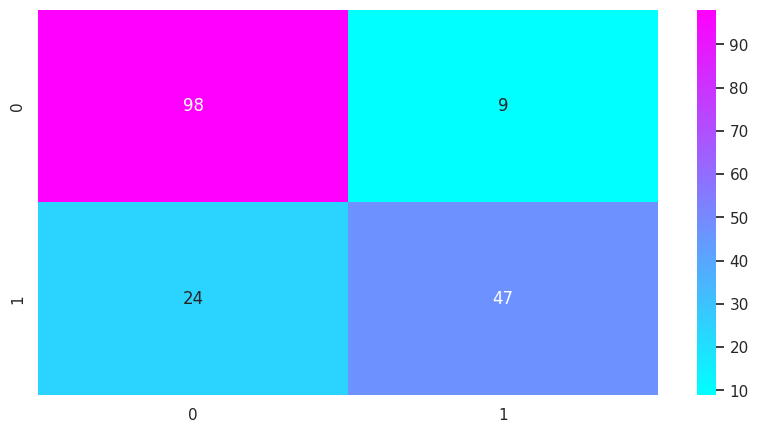

In [128]:
plt.figure(figsize=(10, 5))
sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='cool')
plt.show()

In [129]:
print('Accuracy of Logistic Regression model is  : ', (metrics.accuracy_score(y_test, y_pred)))
print('Recall of Logistic Regression model is    : ', (metrics.recall_score(y_test, y_pred)))
print('Precision of Logistic Regression model is : ', (metrics.precision_score(y_test, y_pred)))

Accuracy of Logistic Regression model is  :  0.8146067415730337
Recall of Logistic Regression model is    :  0.6619718309859155
Precision of Logistic Regression model is :  0.8392857142857143


In [130]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.92      0.86       107
           1       0.84      0.66      0.74        71

    accuracy                           0.81       178
   macro avg       0.82      0.79      0.80       178
weighted avg       0.82      0.81      0.81       178



In [131]:
prediction_prob = LogisticRegression_model.predict_proba(X_test)[:,1]

prediction_prob[prediction_prob > 0.6] = 1
prediction_prob[prediction_prob <= 0.6] = 0

In [132]:
confusion_matrix_prob =pd.crosstab(y_test,prediction_prob)
confusion_matrix_prob

col_0,0.0,1.0
Survived,,
0,102,5
1,29,42


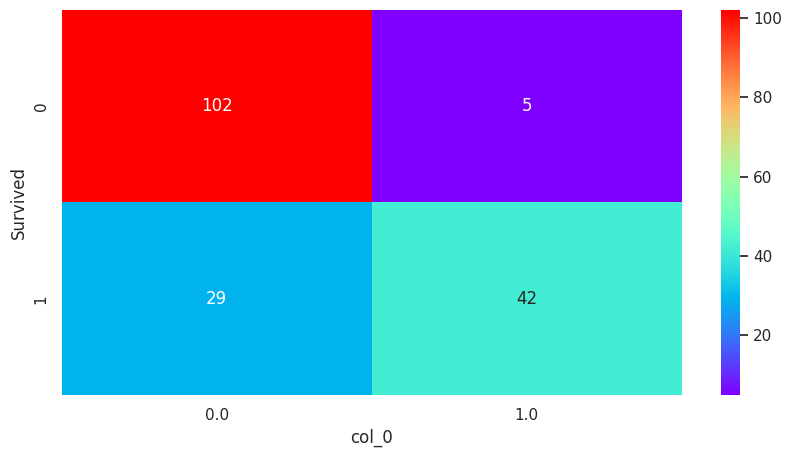

In [133]:
plt.figure(figsize=(10, 5))
sns.heatmap(confusion_matrix_prob, annot=True, fmt='d', cmap='rainbow')
plt.show()

In [134]:
print('Accuracy of Logistic Regression model is  : ', (metrics.accuracy_score(y_test, prediction_prob)))
print('Recall of Logistic Regression model is    : ', (metrics.recall_score(y_test, prediction_prob)))
print('Precision of Logistic Regression model is : ', (metrics.precision_score(y_test, prediction_prob)))

Accuracy of Logistic Regression model is  :  0.8089887640449438
Recall of Logistic Regression model is    :  0.5915492957746479
Precision of Logistic Regression model is :  0.8936170212765957


In [135]:
print(classification_report(y_test,prediction_prob))

              precision    recall  f1-score   support

           0       0.78      0.95      0.86       107
           1       0.89      0.59      0.71        71

    accuracy                           0.81       178
   macro avg       0.84      0.77      0.78       178
weighted avg       0.82      0.81      0.80       178



In [136]:
test_data.isnull().sum()

,0
PassengerId,0
Pclass,0
Name,0
Sex,0
Age,86
SibSp,0
Parch,0
Ticket,0
Fare,1
Cabin,327


<Axes: >

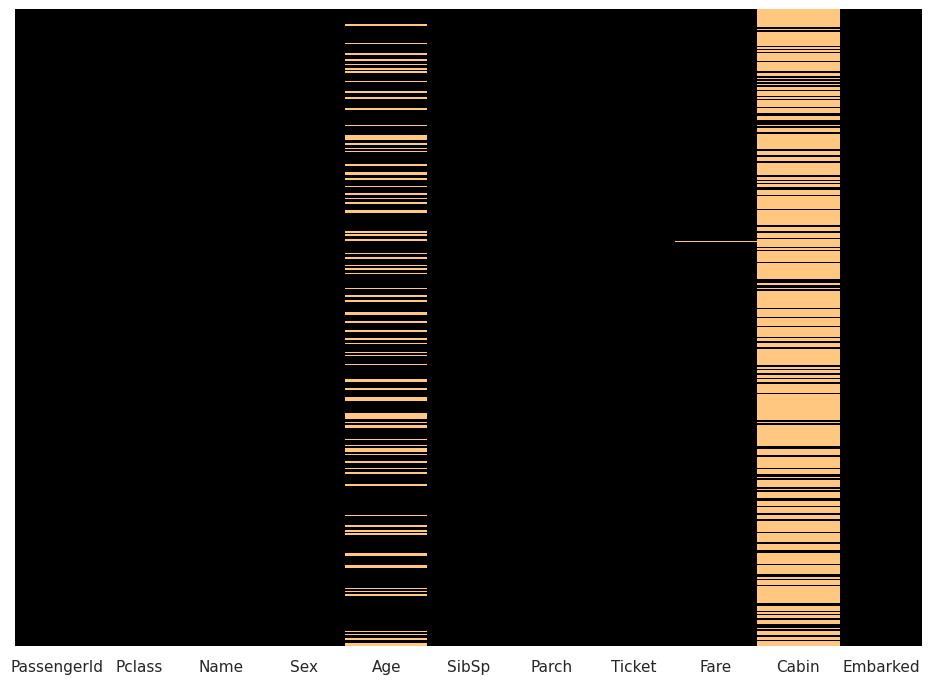

In [138]:
sns.set(rc={'figure.figsize':(11.7,8.27)})
sns.heatmap(test_data.isnull(),yticklabels=False,cbar=False,cmap="copper")

/tmp/ipython-input-3978569677.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




Text(0.5, 1.0, 'Age over Pclass')

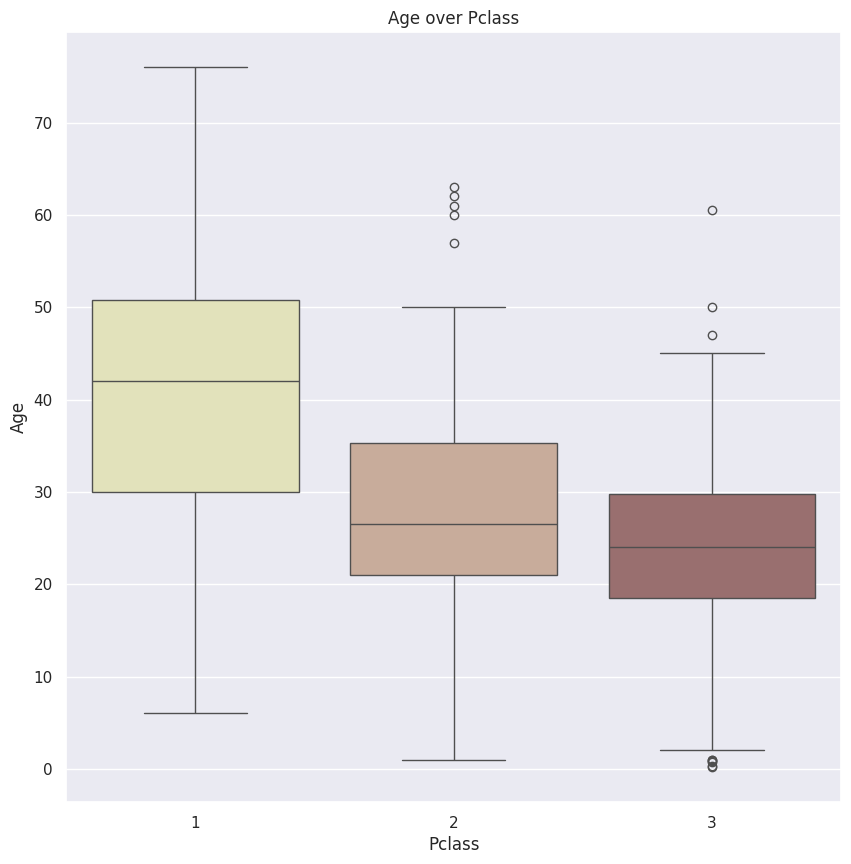

In [139]:
plt.figure(figsize=(10, 10))
sns.boxplot(x='Pclass',y='Age',data=test_data,palette='pink_r')
plt.title('Age over Pclass')

In [140]:
def impute_test_age(cols):
    Age = cols[0]
    Pclass = cols[1]

    if pd.isnull(Age):

        if Pclass == 1:
            return 42

        elif Pclass == 2:
            return 27

        else:
            return 25

    else:
        return Age

In [141]:
test_data['Age'] = test_data[['Age','Pclass']].apply(impute_test_age,axis=1)

/tmp/ipython-input-3601112268.py:2: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipython-input-3601112268.py:3: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



In [142]:
test_data['Age'].isnull().sum()

np.int64(0)

In [143]:
test_data.drop('Cabin',axis=1,inplace=True)

In [144]:
test_data.isnull().sum()

,0
PassengerId,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,1
Embarked,0


In [145]:
null_columns=test_data.columns[test_data.isnull().any()]
row_num = (test_data[test_data["Fare"].isnull()][null_columns])
row_num

,Fare
152,NaN


In [146]:
test_data.iloc[152, :]

,152
PassengerId,1044
Pclass,3
Name,"Storey, Mr. Thomas"
Sex,male
Age,60.5
SibSp,0
Parch,0
Ticket,3701
Fare,NaN
Embarked,S


<Axes: xlabel='Fare', ylabel='Count'>

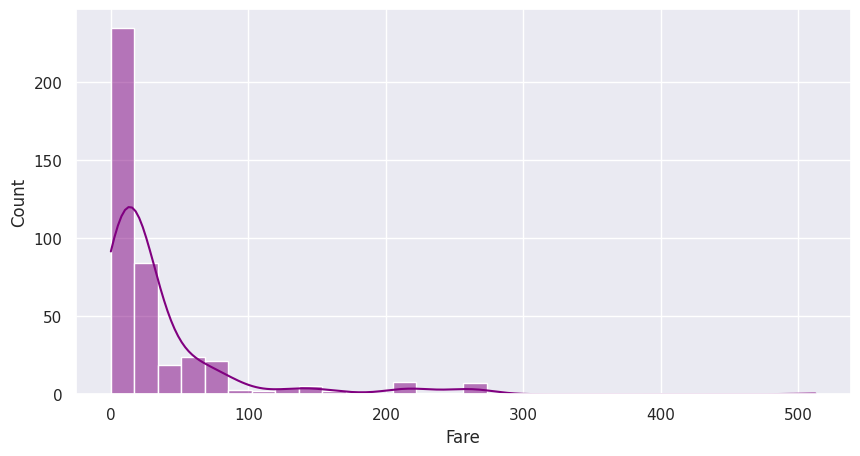

In [147]:
plt.figure(figsize=(10, 5))
sns.histplot(test_data['Fare'].dropna(),kde=True,color='purple',bins=30)

In [148]:
Fare_median = test_data["Fare"].median()
Fare_median

14.4542

In [149]:
test_data = test_data.replace(np.NaN,14.4542)

AttributeError: `np.NaN` was removed in the NumPy 2.0 release. Use `np.nan` instead.

In [150]:
test_data.iloc[152, :]

,152
PassengerId,1044
Pclass,3
Name,"Storey, Mr. Thomas"
Sex,male
Age,60.5
SibSp,0
Parch,0
Ticket,3701
Fare,NaN
Embarked,S


In [151]:
test_data.isnull().sum()

,0
PassengerId,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,1
Embarked,0


In [152]:
test_data.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,S


In [153]:
test_pass = test_data['PassengerId']
test_pass

,PassengerId
0,892
1,893
2,894
3,895
4,896
...,...
413,1305
414,1306
415,1307
416,1308


In [154]:
test_data.drop(['Name','Ticket','PassengerId'],axis=1,inplace=True)

In [155]:
test_data.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,34.5,0,0,7.8292,Q
1,3,female,47.0,1,0,7.0000,S
2,2,male,62.0,0,0,9.6875,Q
3,3,male,27.0,0,0,8.6625,S
4,3,female,22.0,1,1,12.2875,S


In [156]:
test_data = pd.get_dummies(test_data, columns = ['Sex', 'Embarked'], drop_first=True)

In [157]:
test_data.head()

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,3,34.5,0,0,7.8292,True,True,False
1,3,47.0,1,0,7.0000,False,False,True
2,2,62.0,0,0,9.6875,True,True,False
3,3,27.0,0,0,8.6625,True,False,True
4,3,22.0,1,1,12.2875,False,False,True


In [158]:
X1_Train = train_data.drop(['Survived'],axis = 1)
y1_Train = train_data['Survived']

In [159]:
cols = test_data.columns

scal = RobustScaler()

X1_Train = scal.fit_transform(X1_Train)
test_data = scal.transform(test_data)

In [160]:
X1_Train = pd.DataFrame(X1_Train,columns=cols)
test_data = pd.DataFrame(test_data,columns=cols)

In [161]:
X1_Train.head()

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0.0,-0.275862,1.0,0.0,-0.311813,0.0,0.0,0.0
1,-2.0,0.827586,1.0,0.0,2.459687,-1.0,0.0,-1.0
2,0.0,0.000000,0.0,0.0,-0.282598,-1.0,0.0,0.0
3,-2.0,0.620690,1.0,0.0,1.672674,-1.0,0.0,0.0
4,0.0,0.620690,0.0,0.0,-0.277188,0.0,0.0,0.0


In [162]:
test_data.head()

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0.0,0.586207,0.0,0.0,-0.286744,0.0,1.0,-1.0
1,0.0,1.448276,1.0,0.0,-0.322634,-1.0,0.0,0.0
2,-1.0,2.482759,0.0,0.0,-0.206313,0.0,1.0,-1.0
3,0.0,0.068966,0.0,0.0,-0.250677,0.0,0.0,0.0
4,0.0,-0.275862,1.0,1.0,-0.093779,-1.0,0.0,0.0


In [163]:
LogisticRegression_model.fit(X1_Train,y1_Train)

LogisticRegression(max_iter=4000)

In [164]:
y_pred_2 = LogisticRegression_model.predict(test_data)

ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [165]:
y_pred_2

NameError: name 'y_pred_2' is not defined

In [166]:
submission = pd.DataFrame({'PassengerId': test_pass, 'Survived': y_pred_2})
submission

NameError: name 'y_pred_2' is not defined

In [167]:
submission.to_csv('submission.csv',index=False)

NameError: name 'submission' is not defined